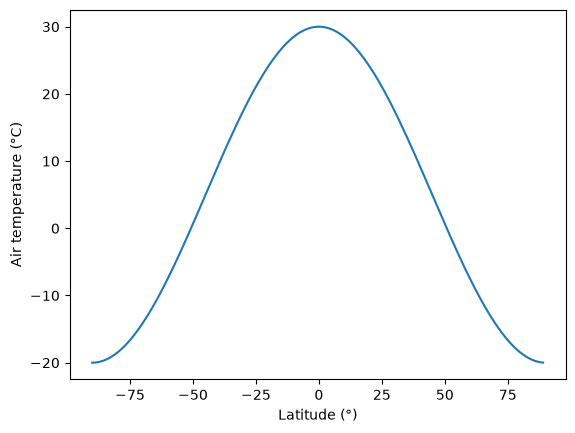

In [1]:
def temperature(lat):
    return 5 + 25*np.cos(2*np.deg2rad(lat))

import matplotlib.pyplot as plt
import numpy as np

lats = np.arange(-90, 90, 1)
temperatures = temperature(lats)

plt.plot(lats, temperatures)
plt.xlabel("Latitude (°)")
plt.ylabel("Air temperature (°C)")
plt.show()

In [2]:
import numpy as np
import pandas as pd

from healpix_geo.nested import healpix_to_lonlat

def compute_mean(ellipsoid, depth=6):

    # Total number of cells at this depth
    n_cells = 12 * (4 ** depth)

    # HEALPix cell ids covering the entire Earth
    ipix = np.arange(n_cells, dtype=np.uint64)

    # Cell-center coordinates on the WGS84 ellipsoid
    lon, lat = healpix_to_lonlat(
        ipix,
        depth=depth,
        ellipsoid=ellipsoid,
    )

    temps = temperature(lat)

    # Equal-area HEALPix => arithmetic mean is the global mean
    print(f"Global mean temperature = {temps.mean():.6f}°")

    return temps.mean()

In [3]:
for depth in range(5, 12):
    print(f"\nDepth = {depth}")
    compute_mean(ellipsoid="sphere", depth=depth)
    compute_mean(ellipsoid="WGS84", depth=depth)


Depth = 5
Global mean temperature = 13.334841°
Global mean temperature = 13.275081°

Depth = 6
Global mean temperature = 13.333710°
Global mean temperature = 13.273955°

Depth = 7
Global mean temperature = 13.333428°
Global mean temperature = 13.273674°

Depth = 8
Global mean temperature = 13.333357°
Global mean temperature = 13.273603°

Depth = 9
Global mean temperature = 13.333339°
Global mean temperature = 13.273586°

Depth = 10
Global mean temperature = 13.333335°
Global mean temperature = 13.273581°

Depth = 11
Global mean temperature = 13.333334°
Global mean temperature = 13.273580°
